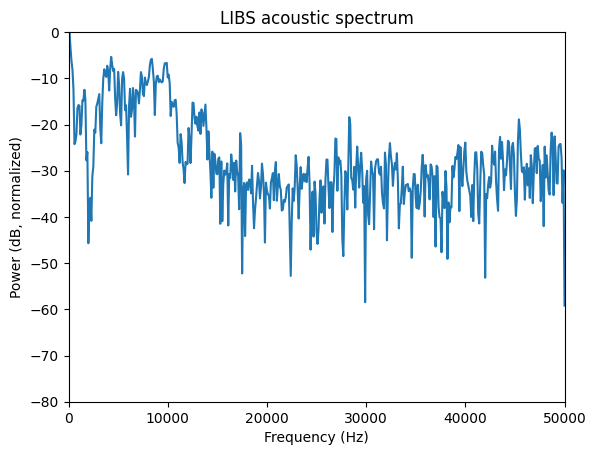

In [2]:
import numpy as np
from scipy.io import wavfile
from scipy.signal import windows
import matplotlib.pyplot as plt

fs, x = wavfile.read(r"C:\Users\cmkua\Downloads\ALANA\scam_0087_0674660453_555_ca0_scam01087_hastah_tsaadah_______01p01.wav")

# if stereo, take one channel
if x.ndim > 1:
    x = x[:, 0]

# normalize
x = x.astype(float)
x = x / np.max(np.abs(x))

# example: first 10 ms after known onset sample
onset_sample = 7000  # replace with your detected onset
N = int(0.010 * fs)

seg = x[onset_sample:onset_sample + N]
seg = seg - np.mean(seg)

w = windows.hann(len(seg))
seg_w = seg * w

freqs = np.fft.rfftfreq(len(seg_w), d=1/fs)
X = np.fft.rfft(seg_w)
power = np.abs(X)**2

plt.plot(freqs, 10*np.log10(power / np.max(power)))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (dB, normalized)")
plt.title("LIBS acoustic spectrum")
plt.xlim(0, fs/2)
plt.ylim(-80, 0)
plt.show()

Sample size by member:
Member
Undivided    41
Nataani      38
Rochette     24
Bastide      22
Roubion      11
Caille       10
Cha'al        9
Content       8
Artuby        7
Name: count, dtype: int64



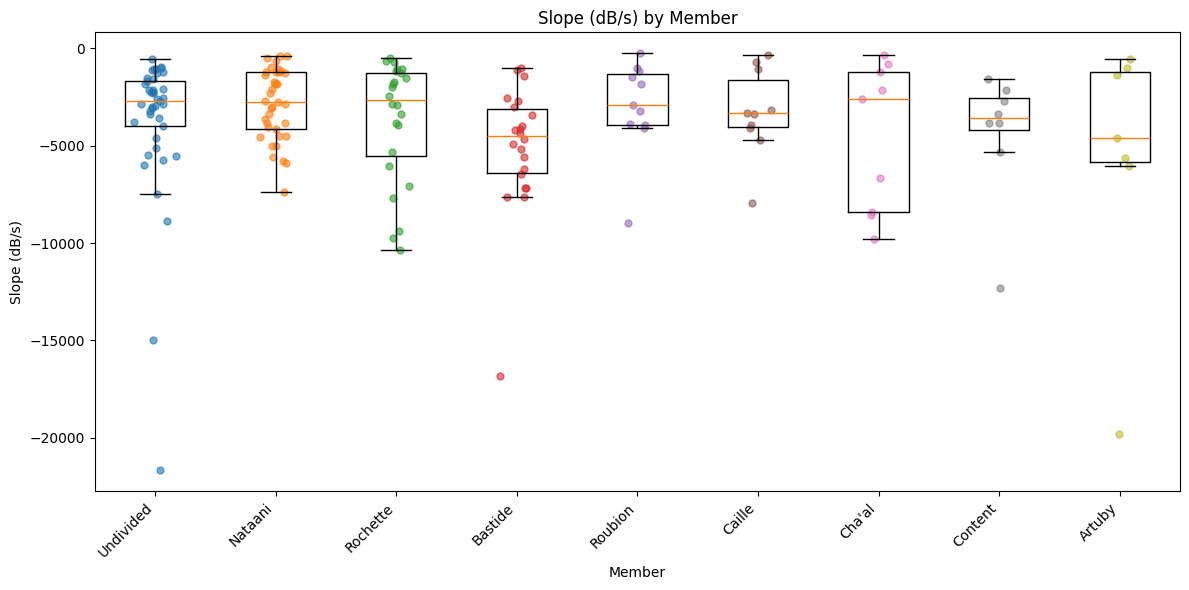

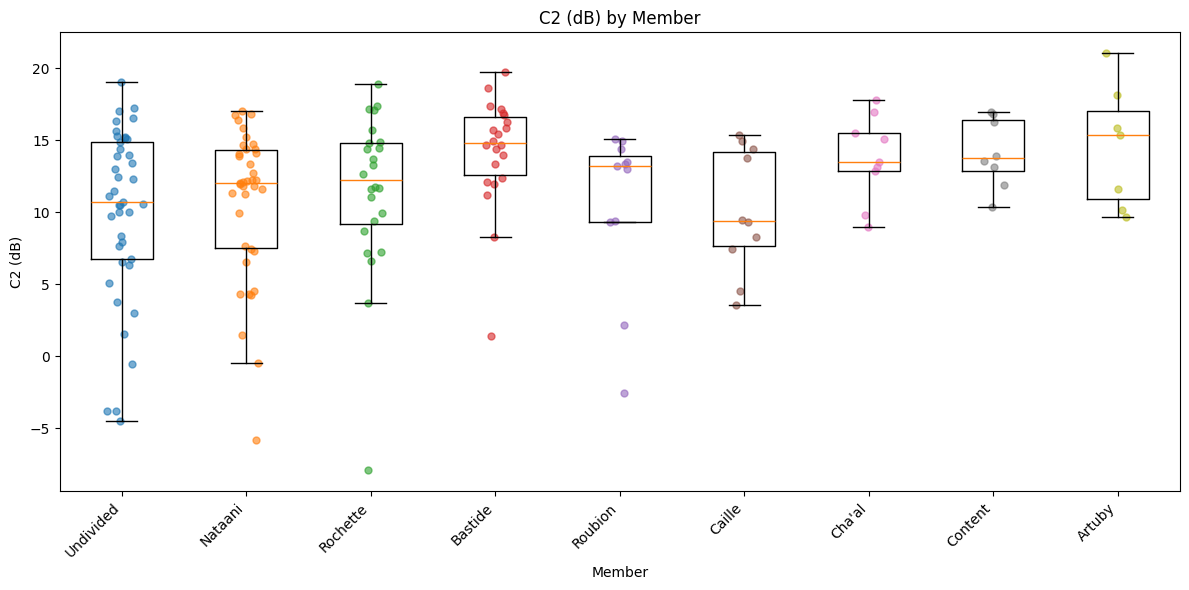

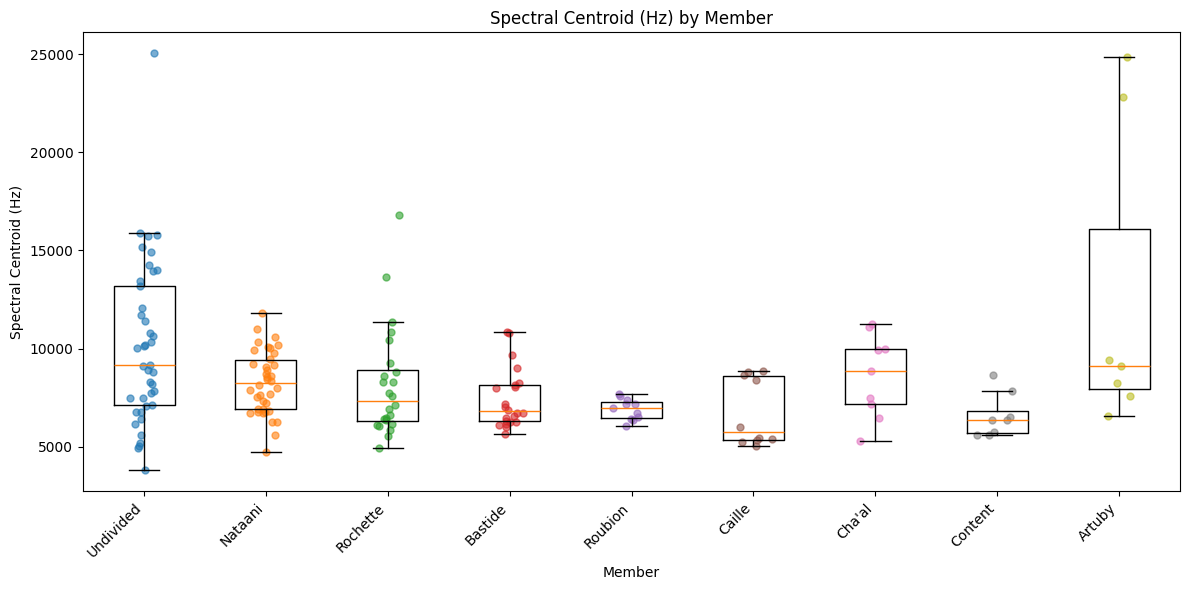

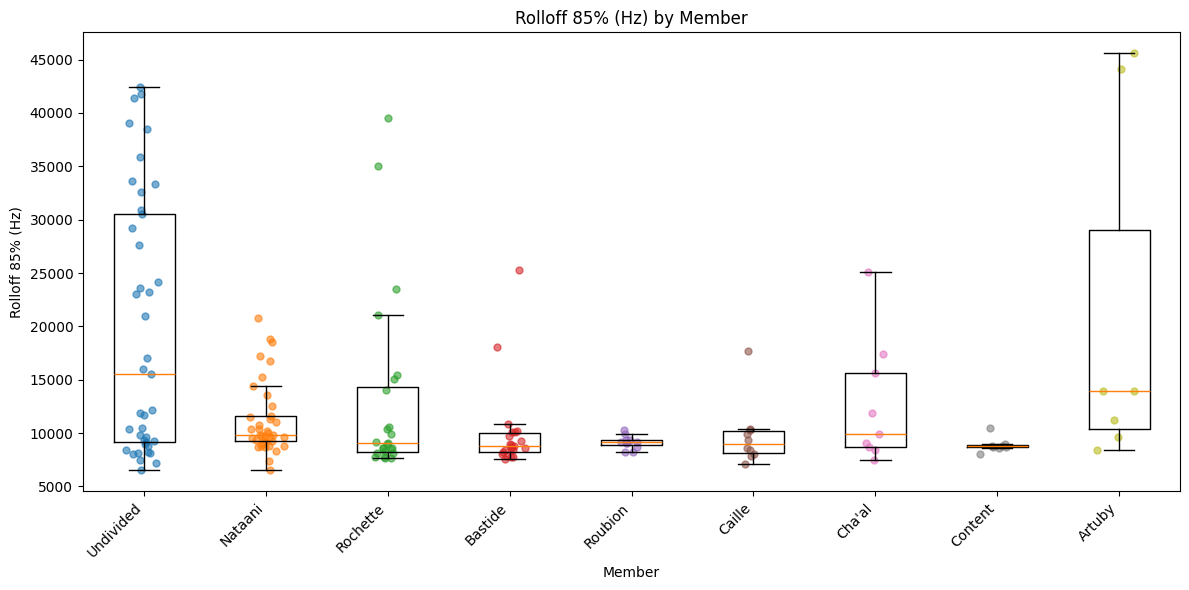

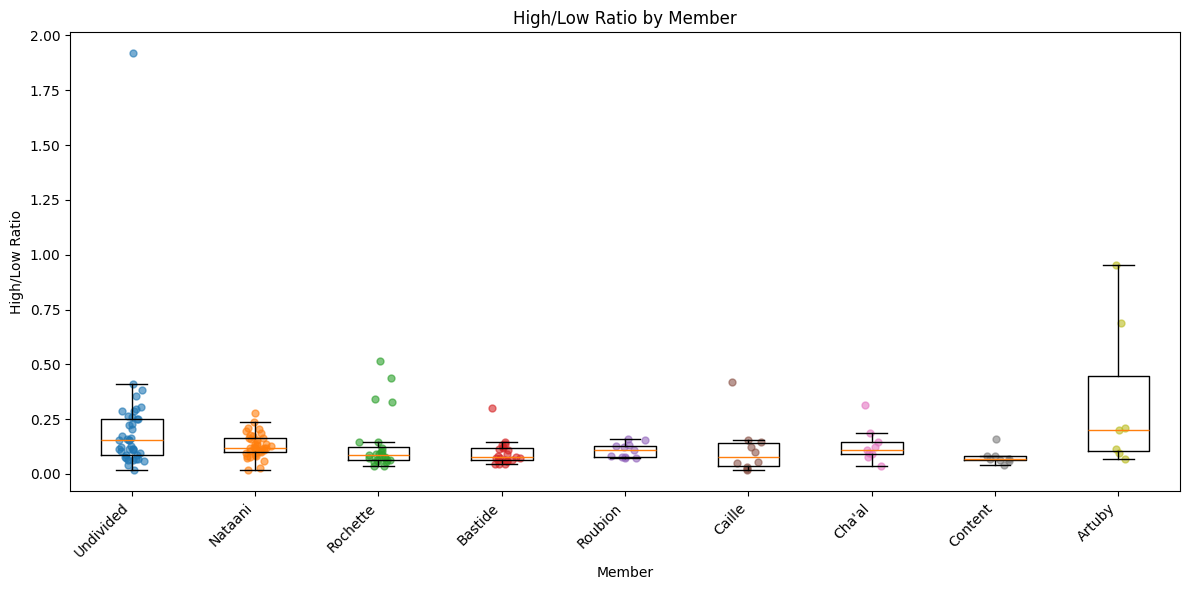

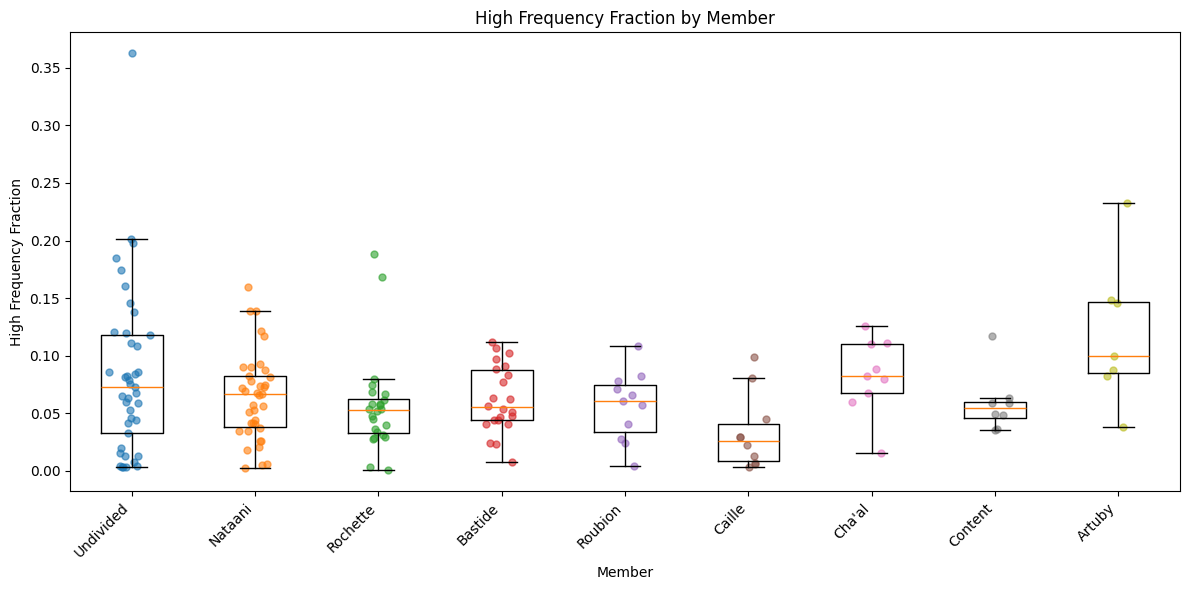

Plots saved to:
C:\Users\cmkua\Downloads\LIBS_170_plots


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# ============================================================
# LOAD EXPANDED DATASET
# ============================================================

file_path = r"C:\Users\cmkua\Downloads\LIBS_acoustic_meta_sheet_expanded.csv"

df = pd.read_csv(file_path)

# Clean member names just in case
df["Member"] = df["Member"].astype(str).str.strip()

# ============================================================
# METRICS TO PLOT
# ============================================================

metrics = [
    "Slope (dB/s)",
    "C2 (dB)",
    "Spectral Centroid (Hz)",
    "Rolloff 85% (Hz)",
    "High/Low Ratio",
    "High Frequency Fraction"
]

# Only keep metrics that actually exist
metrics = [m for m in metrics if m in df.columns]

# Order members by sample size, descending
member_order = df["Member"].value_counts().index.tolist()

print("Sample size by member:")
print(df["Member"].value_counts())
print()

# ============================================================
# OUTPUT FOLDER
# ============================================================

plot_folder = r"C:\Users\cmkua\Downloads\LIBS_170_plots"
os.makedirs(plot_folder, exist_ok=True)

# ============================================================
# BOXPLOT + JITTER FUNCTION
# ============================================================

def boxplot_with_jitter(df, group_col, metric, order, save=True):
    fig, ax = plt.subplots(figsize=(12, 6))

    data = [
        df[df[group_col] == group][metric].dropna()
        for group in order
    ]

    ax.boxplot(
        data,
        tick_labels=order,
        showfliers=False
    )

    for i, group in enumerate(order):
        y = df[df[group_col] == group][metric].dropna()
        x = np.random.normal(i + 1, 0.06, len(y))
        ax.scatter(x, y, alpha=0.6, s=25)

    ax.set_title(f"{metric} by {group_col}")
    ax.set_xlabel(group_col)
    ax.set_ylabel(metric)

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    if save:
        safe_metric = (
            metric.replace("/", "_")
            .replace(" ", "_")
            .replace("(", "")
            .replace(")", "")
            .replace("%", "pct")
        )
        save_path = os.path.join(
            plot_folder,
            f"{safe_metric}_by_{group_col}.png"
        )
        plt.savefig(save_path, dpi=300)

    plt.show()

# ============================================================
# MEMBER PLOTS
# ============================================================

for metric in metrics:
    boxplot_with_jitter(
        df=df,
        group_col="Member",
        metric=metric,
        order=member_order,
        save=True
    )

print("Plots saved to:")
print(plot_folder)

Sample size by formation:
Formation
Maaz      97
Seitah    73
Name: count, dtype: int64



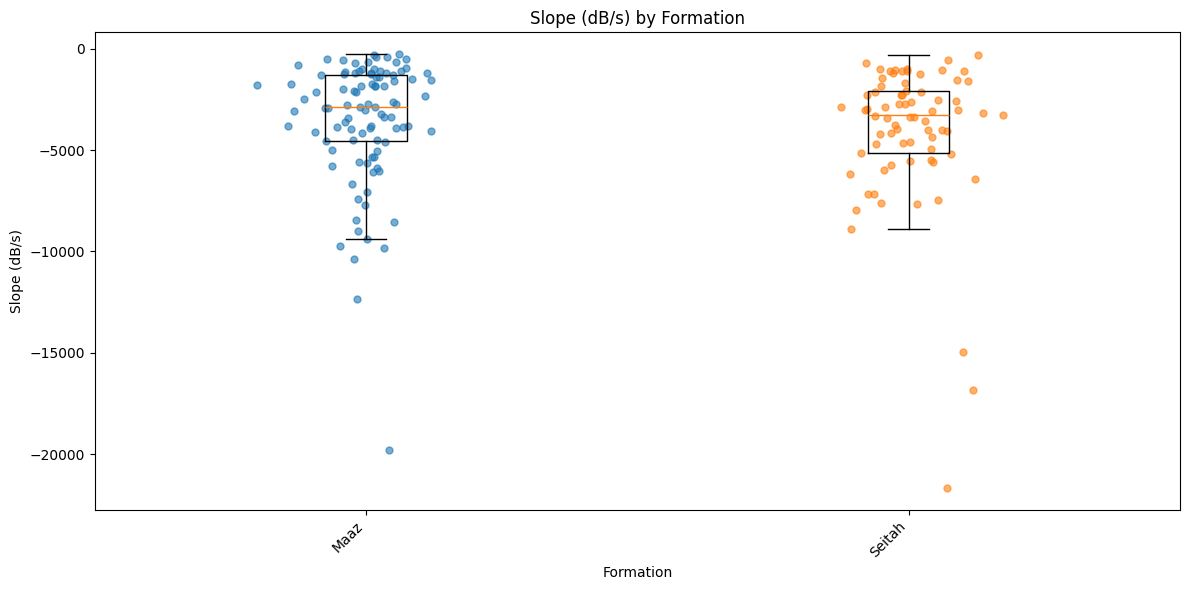

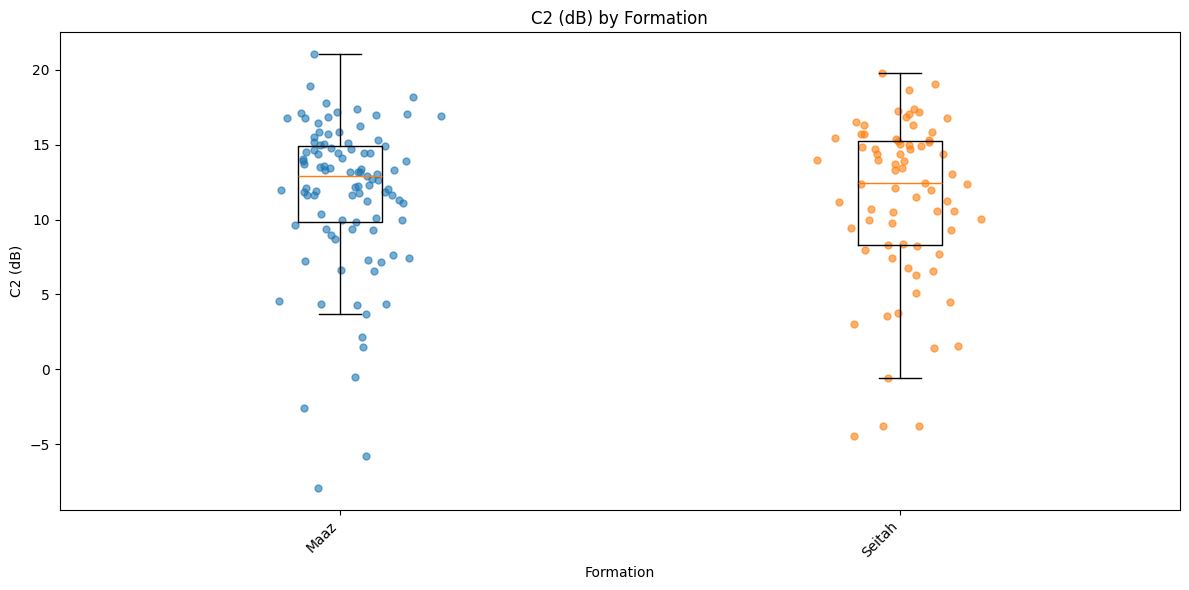

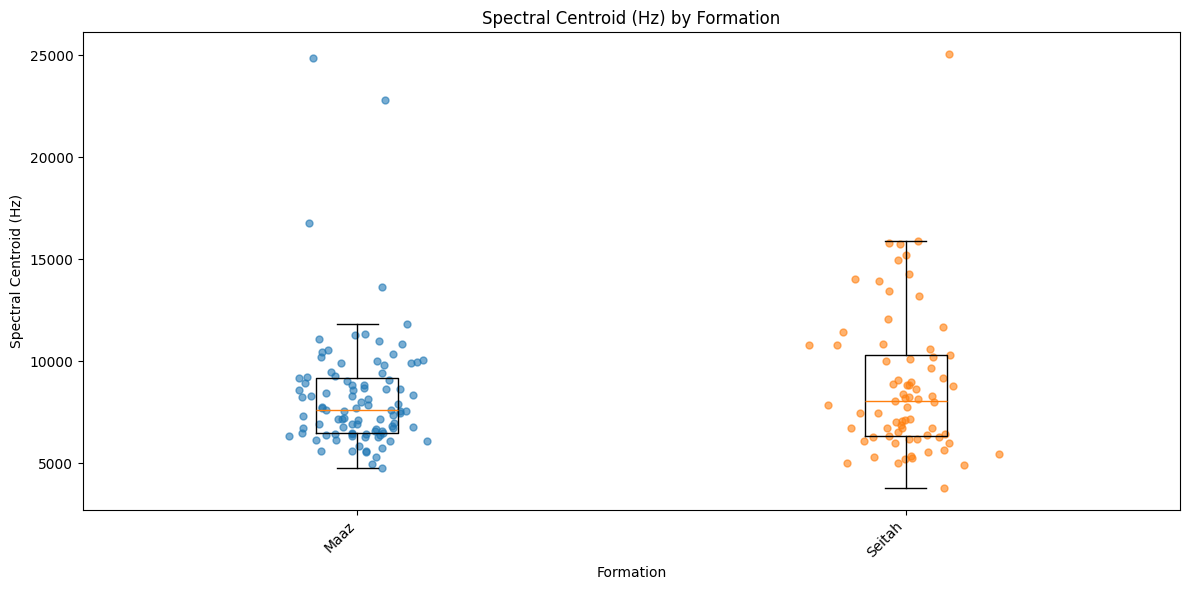

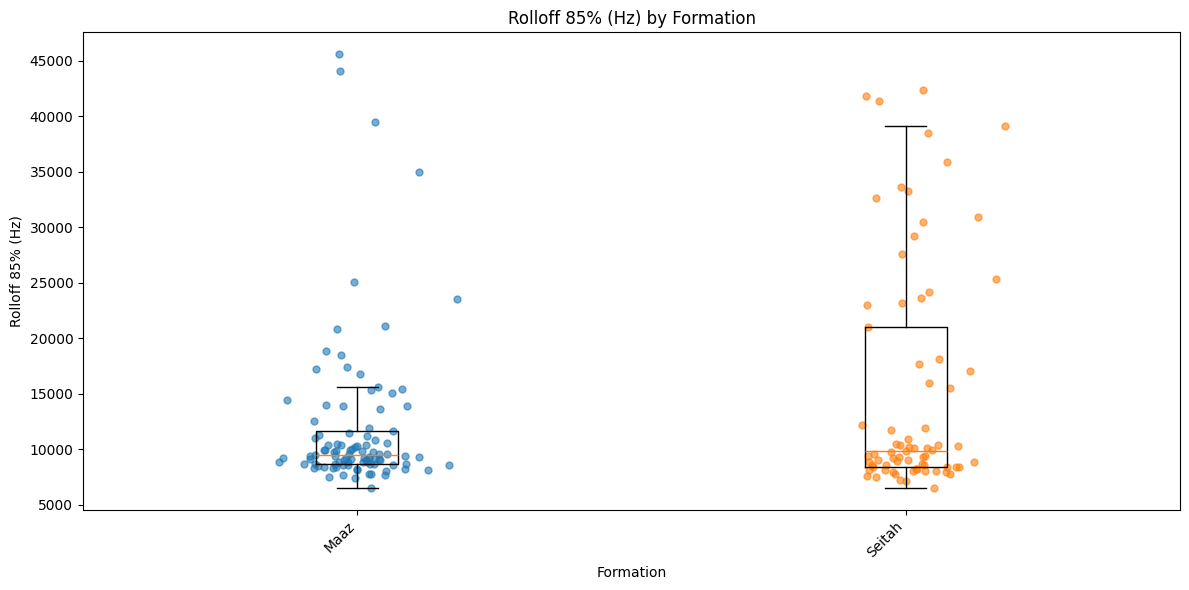

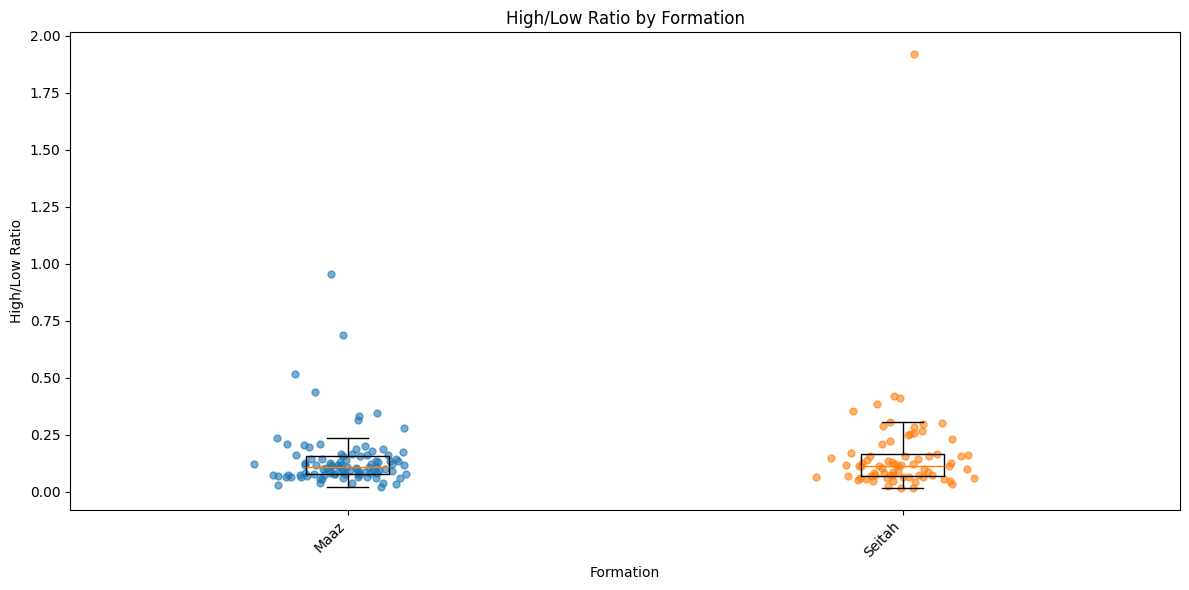

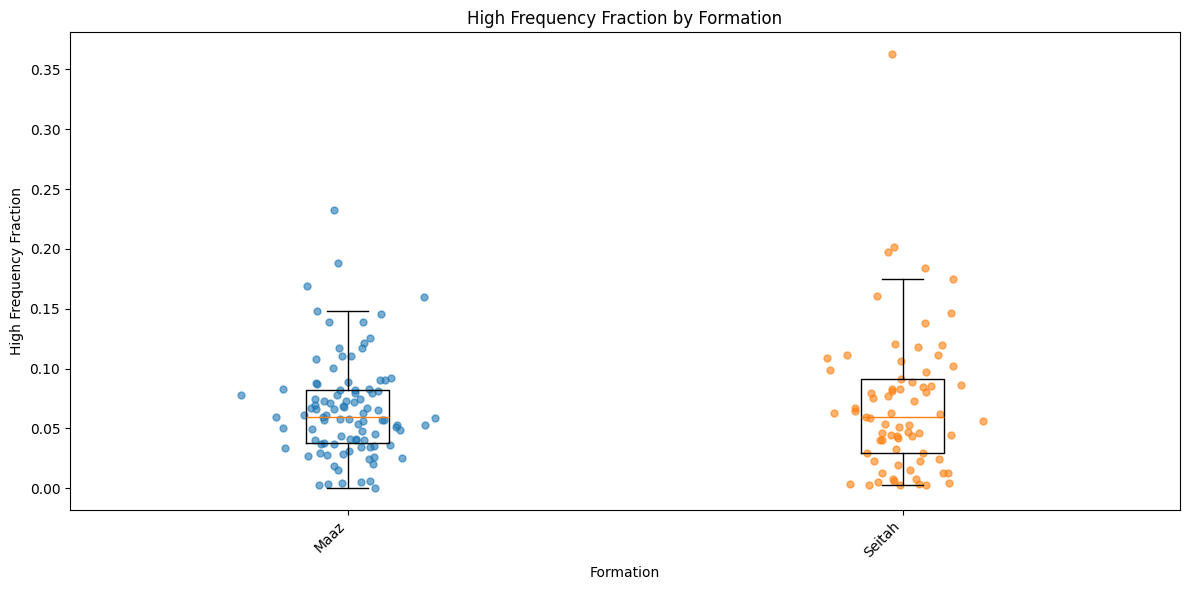

In [2]:
# ============================================================
# CREATE FORMATION COLUMN
# ============================================================

seitah_members = ["Bastide", "Undivided", "Caille"]

df["Formation"] = df["Member"].apply(
    lambda m: "Seitah" if m in seitah_members else "Maaz"
)

formation_order = ["Maaz", "Seitah"]

print("Sample size by formation:")
print(df["Formation"].value_counts())
print()

# ============================================================
# FORMATION PLOTS
# ============================================================

for metric in metrics:
    boxplot_with_jitter(
        df=df,
        group_col="Formation",
        metric=metric,
        order=formation_order,
        save=True
    )

In [2]:
from scipy.signal import windows

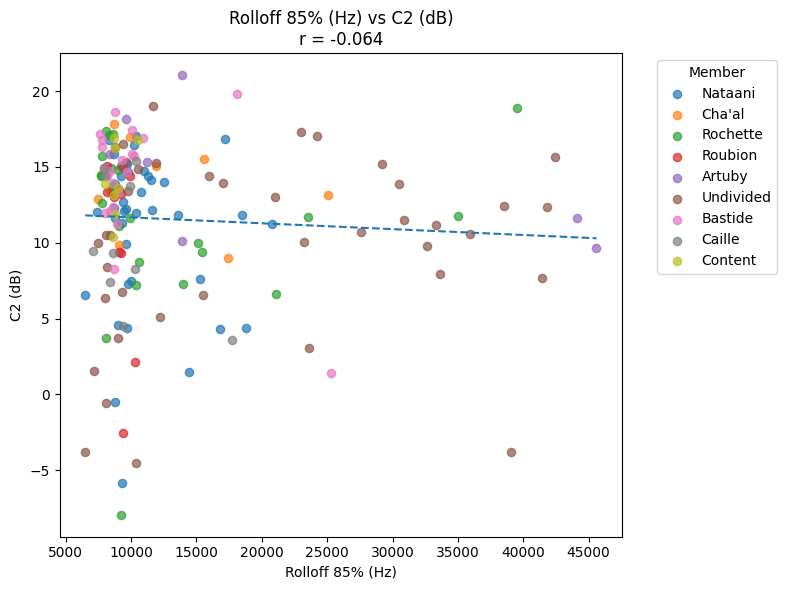

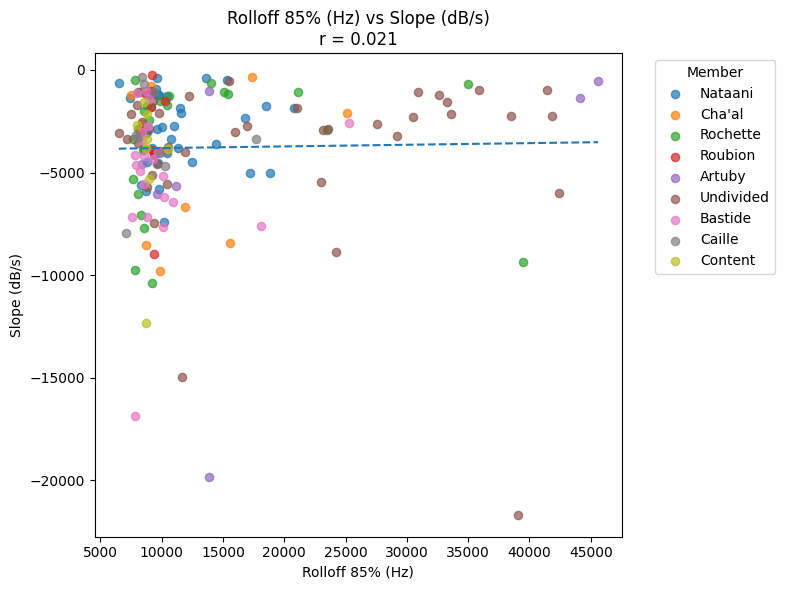

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

file_path = r"C:\Users\cmkua\Downloads\LIBS_acoustic_meta_sheet_expanded.csv"
df = pd.read_csv(file_path)

x_col = "Rolloff 85% (Hz)"
y_cols = ["C2 (dB)", "Slope (dB/s)"]

members = df["Member"].dropna().unique()

for y_col in y_cols:
    plot_df = df[[x_col, y_col, "Member"]].dropna()

    plt.figure(figsize=(8, 6))

    for member in members:
        sub = plot_df[plot_df["Member"] == member]
        plt.scatter(
            sub[x_col],
            sub[y_col],
            label=member,
            alpha=0.7,
            s=35
        )

    # regression line
    x = plot_df[x_col].values
    y = plot_df[y_col].values

    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = m * x_line + b

    plt.plot(x_line, y_line, linestyle="--")

    corr = np.corrcoef(x, y)[0, 1]

    plt.title(f"{x_col} vs {y_col}\nr = {corr:.3f}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend(title="Member", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

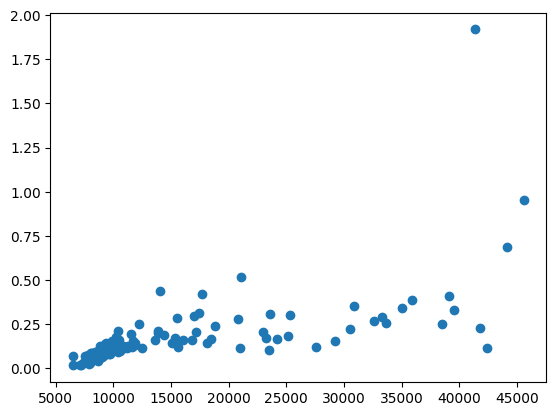

In [5]:
plt.scatter(
    df["Rolloff 85% (Hz)"],
    df["High/Low Ratio"]
)


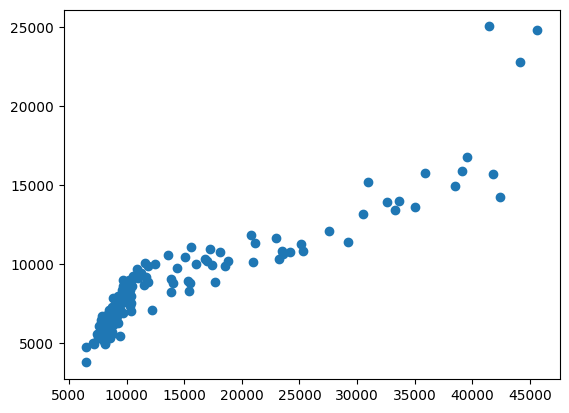

In [4]:
plt.scatter(
    df["Rolloff 85% (Hz)"],
    df["Spectral Centroid (Hz)"]
)

In [6]:
freq_metrics = [
    "Rolloff 85% (Hz)",
    "Spectral Centroid (Hz)",
    "High/Low Ratio",
    "High Frequency Fraction",
    "Spectral Bandwidth (Hz)"
]

print(df[freq_metrics].corr())

                         Rolloff 85% (Hz)  Spectral Centroid (Hz)  \
Rolloff 85% (Hz)                 1.000000                0.916223   
Spectral Centroid (Hz)           0.916223                1.000000   
High/Low Ratio                   0.653808                0.789963   
High Frequency Fraction          0.543660                0.674098   
Spectral Bandwidth (Hz)          0.842622                0.866470   

                         High/Low Ratio  High Frequency Fraction  \
Rolloff 85% (Hz)               0.653808                 0.543660   
Spectral Centroid (Hz)         0.789963                 0.674098   
High/Low Ratio                 1.000000                 0.624824   
High Frequency Fraction        0.624824                 1.000000   
Spectral Bandwidth (Hz)        0.536172                 0.500643   

                         Spectral Bandwidth (Hz)  
Rolloff 85% (Hz)                        0.842622  
Spectral Centroid (Hz)                  0.866470  
High/Low Ratio         

In [7]:
summary = (
    df.groupby("Member")[
        ["Rolloff 85% (Hz)",
         "Spectral Centroid (Hz)",
         "High/Low Ratio"]
    ]
    .mean()
)

print(summary.sort_values("Rolloff 85% (Hz)", ascending=False))

           Rolloff 85% (Hz)  Spectral Centroid (Hz)  High/Low Ratio
Member                                                             
Artuby         20957.142857            12653.853727        0.332991
Undivided      19612.195122            10159.860492        0.210365
Rochette       12983.333333             8180.491531        0.135552
Cha'al         12622.222222             8611.582560        0.131056
Nataani        11184.210526             8267.690260        0.130097
Bastide        10018.181818             7411.613701        0.095282
Caille          9770.000000             6715.106524        0.111990
Roubion         9154.545455             6916.989619        0.108107
Content         8887.500000             6580.232997        0.077046


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.stats import linregress
from scipy.signal import find_peaks, windows
import os
import pandas as pd

# ============================================================
# SETTINGS
# ============================================================

base_folder = r"C:\Users\cmkua\Downloads\ALANA"

files = sorted([
    f for f in os.listdir(base_folder)
    if f.lower().endswith(".wav")
])

show_detection_plots = False

expected_shot_time = 0.073
next_shot_start = 0.133

response_window = 0.010

fit_db_top = -7
fit_db_bottom = -15

t_c = 0.002

search_half_width = 0.005
noise_window = 0.003
smooth_window_s = 0.00005
threshold_sigma = 4

min_peak_distance_s = 0.010
prominence_sigma = 3
height_sigma = 4

backtrack_window_s = 0.003
backtrack_noise_s = 0.005
backtrack_sigma = 4
min_run_s = 0.00005
flag_lag_ms = 0.4

# FFT settings
usable_band = (1000, 50000)
low_band = (1000, 10000)
high_band = (10000, 30000)

# ============================================================
# FFT METRICS
# ============================================================

def compute_fft_metrics(segment, fs):
    segment = segment - np.mean(segment)

    hann = windows.hann(len(segment))
    seg_w = segment * hann

    freqs = np.fft.rfftfreq(len(seg_w), d=1/fs)
    X = np.fft.rfft(seg_w)
    power = np.abs(X) ** 2

    usable_mask = (freqs >= usable_band[0]) & (freqs <= usable_band[1])
    f = freqs[usable_mask]
    p = power[usable_mask]

    if len(p) == 0 or np.sum(p) == 0:
        return {
            "Spectral Centroid (Hz)": np.nan,
            "Spectral Bandwidth (Hz)": np.nan,
            "Peak Frequency (Hz)": np.nan,
            "Rolloff 85% (Hz)": np.nan,
            "Low Power 1-10 kHz": np.nan,
            "High Power 10-30 kHz": np.nan,
            "High/Low Ratio": np.nan,
            "High Frequency Fraction": np.nan,
            "Total FFT Power": np.nan
        }

    p_sum = np.sum(p)

    centroid = np.sum(f * p) / p_sum
    bandwidth = np.sqrt(np.sum(((f - centroid) ** 2) * p) / p_sum)
    peak_freq = f[np.argmax(p)]

    cumulative = np.cumsum(p)
    rolloff_85 = f[np.where(cumulative >= 0.85 * p_sum)[0][0]]

    low_mask = (freqs >= low_band[0]) & (freqs < low_band[1])
    high_mask = (freqs >= high_band[0]) & (freqs < high_band[1])

    low_power = np.sum(power[low_mask])
    high_power = np.sum(power[high_mask])
    total_power = np.sum(power)

    high_low_ratio = high_power / low_power if low_power > 0 else np.nan
    high_freq_fraction = high_power / total_power if total_power > 0 else np.nan

    return {
        "Spectral Centroid (Hz)": centroid,
        "Spectral Bandwidth (Hz)": bandwidth,
        "Peak Frequency (Hz)": peak_freq,
        "Rolloff 85% (Hz)": rolloff_85,
        "Low Power 1-10 kHz": low_power,
        "High Power 10-30 kHz": high_power,
        "High/Low Ratio": high_low_ratio,
        "High Frequency Fraction": high_freq_fraction,
        "Total FFT Power": total_power
    }

# ============================================================
# MAIN LOOP
# ============================================================

results = []

for filename in files:
    wav_path = os.path.join(base_folder, filename)
    print("=" * 80)
    print(wav_path)

    fs, x = wavfile.read(wav_path)
    x = x.astype(np.float64)

    if x.ndim > 1:
        x = x.mean(axis=1)

    x = x - np.mean(x)
    abs_x = np.abs(x)

    smooth_n = max(1, int(round(smooth_window_s * fs)))
    kernel = np.ones(smooth_n) / smooth_n
    env = np.convolve(abs_x, kernel, mode="same")

    search_start = expected_shot_time - search_half_width
    search_end = expected_shot_time + search_half_width

    isearch0 = max(0, int(round(search_start * fs)))
    isearch1 = min(len(x), int(round(search_end * fs)))

    inoise1 = isearch0
    inoise0 = max(0, int(round((search_start - noise_window) * fs)))

    noise_env = env[inoise0:inoise1]
    noise_mean = np.mean(noise_env)
    noise_std = np.std(noise_env)

    threshold = noise_mean + threshold_sigma * noise_std
    search_env = env[isearch0:isearch1]

    min_peak_distance = int(round(min_peak_distance_s * fs))
    min_prominence = prominence_sigma * noise_std
    min_height = noise_mean + height_sigma * noise_std

    peaks, props = find_peaks(
        search_env,
        height=min_height,
        prominence=min_prominence,
        distance=min_peak_distance
    )

    found_onset = len(peaks) > 0
    flagged = False
    lag_ms = np.nan

    if found_onset:
        best_peak_local = peaks[0]
        peak_index = isearch0 + best_peak_local
        peak_time = peak_index / fs

        backtrack_samples = int(round(backtrack_window_s * fs))
        back_start = max(isearch0, peak_index - backtrack_samples)

        noise_back_start = max(0, back_start - int(round(backtrack_noise_s * fs)))
        noise_back_end = back_start
        local_noise = env[noise_back_start:noise_back_end]

        if len(local_noise) > 0:
            local_noise_mean = np.mean(local_noise)
            local_noise_std = np.std(local_noise)
            onset_threshold = local_noise_mean + backtrack_sigma * local_noise_std
        else:
            onset_threshold = threshold

        search_back_env = env[back_start:peak_index]
        above = search_back_env > onset_threshold

        min_run_samples = max(1, int(round(min_run_s * fs)))
        onset_index = None

        for i in range(len(above) - min_run_samples + 1):
            if np.all(above[i:i + min_run_samples]):
                onset_index = back_start + i
                break

        if onset_index is None:
            onset_index = peak_index
            flagged = True
            print("Warning: no clean onset found before peak. Using peak as onset.")

        response_start = onset_index / fs
        response_stop = response_start + response_window

        lag_ms = (peak_index - onset_index) / fs * 1000

        if lag_ms > flag_lag_ms:
            flagged = True
            print(f"Warning: peak is {lag_ms:.3f} ms after onset. Review this file.")

        if response_stop > next_shot_start:
            response_stop = next_shot_start
            print("Warning: window truncated to avoid next shot overlap.")

        i0 = onset_index
        i1 = int(round(response_stop * fs))

        segment = x[i0:i1]
        t = np.arange(len(segment)) / fs

        energy = segment ** 2
        edc = np.cumsum(energy[::-1])[::-1]

        edc_norm = edc / np.max(edc)
        edc_db = 10 * np.log10(edc_norm + 1e-20)

        fit_mask = (edc_db <= fit_db_top) & (edc_db >= fit_db_bottom)

        if np.sum(fit_mask) < 2:
            slope = np.nan
            intercept = np.nan
            r_value = np.nan
            fit_line = np.full_like(edc_db, np.nan)
            drop_time = np.nan
        else:
            slope, intercept, r_value, p_value, std_err = linregress(
                t[fit_mask], edc_db[fit_mask]
            )
            fit_line = slope * t + intercept
            db_drop = abs(fit_db_bottom - fit_db_top)
            drop_time = db_drop / abs(slope) if slope != 0 else np.nan

        i_c = int(round(t_c * fs))

        early_energy = np.sum(energy[:i_c])
        late_energy = np.sum(energy[i_c:])

        C2 = 10 * np.log10(early_energy / late_energy) if late_energy > 0 else np.nan

        fft_metrics = compute_fft_metrics(segment, fs)

    else:
        print("No peak detected in search window.")

        response_start = np.nan
        response_stop = np.nan
        peak_time = np.nan
        onset_threshold = np.nan

        segment = None
        t = None
        edc_db = None
        fit_mask = None
        fit_line = None

        slope = np.nan
        intercept = np.nan
        r_value = np.nan
        drop_time = np.nan
        C2 = np.nan

        fft_metrics = {
            "Spectral Centroid (Hz)": np.nan,
            "Spectral Bandwidth (Hz)": np.nan,
            "Peak Frequency (Hz)": np.nan,
            "Rolloff 85% (Hz)": np.nan,
            "Low Power 1-10 kHz": np.nan,
            "High Power 10-30 kHz": np.nan,
            "High/Low Ratio": np.nan,
            "High Frequency Fraction": np.nan,
            "Total FFT Power": np.nan
        }

    print(f"Sample rate: {fs} Hz")
    print(f"Detected peak:  {peak_time:.6f}" if found_onset else "Detected peak:  None")
    print(f"Detected onset: {response_start:.6f}" if found_onset else "Detected onset: None")
    print(f"Peak-onset lag: {lag_ms:.3f} ms" if found_onset else "Peak-onset lag: None")
    print(f"Flagged:        {flagged}")
    print(f"Slope: {slope:.4f} dB/s")
    print(f"R^2: {r_value**2 if np.isfinite(r_value) else np.nan:.4f}")
    print(f"C2 (dB): {C2:.4f}")
    print(f"Spectral Centroid: {fft_metrics['Spectral Centroid (Hz)']:.2f} Hz")
    print(f"High/Low Ratio: {fft_metrics['High/Low Ratio']:.4f}")

    results.append({
        "File Name": filename,
        "Flagged": flagged,
        "Sample Rate (Hz)": fs,
        "Onset (s)": response_start,
        "Peak Time (s)": peak_time,
        "Peak-Onset Lag (ms)": lag_ms,
        "Slope (dB/s)": slope,
        "R^2": r_value**2 if np.isfinite(r_value) else np.nan,
        "Drop Time (s)": drop_time,
        "C2 (dB)": C2,
        **fft_metrics
    })

    if show_detection_plots:
        full_t = np.arange(len(x)) / fs

        fig, axes = plt.subplots(3, 1, figsize=(10, 9))

        axes[0].plot(full_t[isearch0:isearch1], x[isearch0:isearch1])
        if found_onset:
            axes[0].axvline(response_start, linestyle="--", label="Onset")
            axes[0].axvline(peak_time, linestyle=":", label="Peak")
        axes[0].set_title("Search Region")
        axes[0].legend()

        axes[1].plot(full_t[isearch0:isearch1], env[isearch0:isearch1])
        axes[1].axhline(threshold, linestyle=":", label="Peak threshold")
        if found_onset:
            axes[1].axhline(onset_threshold, linestyle="--", label="Onset threshold")
            axes[1].axvline(response_start, linestyle="--")
            axes[1].axvline(peak_time, linestyle=":")
        axes[1].set_title("Envelope")
        axes[1].legend()

        if found_onset:
            axes[2].plot(t, edc_db, label="EDC")
            if np.sum(fit_mask) >= 2:
                axes[2].plot(t, fit_line, "--", label="Fit")
            axes[2].set_title("Energy Decay Curve")
            axes[2].legend()
        else:
            axes[2].text(0.5, 0.5, "No onset detected", ha="center", va="center")

        plt.tight_layout()
        plt.show()

# ============================================================
# EXPORT RESULTS TO CSV
# ============================================================

df = pd.DataFrame(results)

output_path = os.path.join(base_folder, "LIBS_acoustic_frequency_results.csv")
df.to_csv(output_path, index=False)

print("\nResults exported to:")
print(output_path)

C:\Users\cmkua\Downloads\ALANA\scam_0037_0670224261_699_ca0_scam01037_hedgehog_____________01p01.wav
Sample rate: 100000 Hz
Detected peak:  0.070540
Detected onset: 0.070440
Peak-onset lag: 0.100 ms
Flagged:        False
Slope: -2074.3022 dB/s
R^2: 0.9363
C2 (dB): 12.1817
Spectral Centroid: 10066.15 Hz
High/Low Ratio: 0.1184
C:\Users\cmkua\Downloads\ALANA\scam_0037_0670224376_725_ca0_scam01037_hedgehog_____________02p01.wav
Sample rate: 100000 Hz
Detected peak:  0.070730
Detected onset: 0.068290
Peak-onset lag: 2.440 ms
Flagged:        True
Slope: -7764.6520 dB/s
R^2: 0.9611
C2 (dB): -14.1853
Spectral Centroid: 6159.61 Hz
High/Low Ratio: 0.0739
C:\Users\cmkua\Downloads\ALANA\scam_0051_0671472287_263_ca0_scam04051_tselhbahih___________01p01.wav
Sample rate: 100000 Hz
Detected peak:  0.070250
Detected onset: 0.070150
Peak-onset lag: 0.100 ms
Flagged:        False
Slope: -1285.0516 dB/s
R^2: 0.8676
C2 (dB): 11.9819
Spectral Centroid: 7981.69 Hz
High/Low Ratio: 0.1547
C:\Users\cmkua\Downlo

C:\Users\cmkua\AppData\Local\Temp\ipykernel_35060\449163728.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=members)


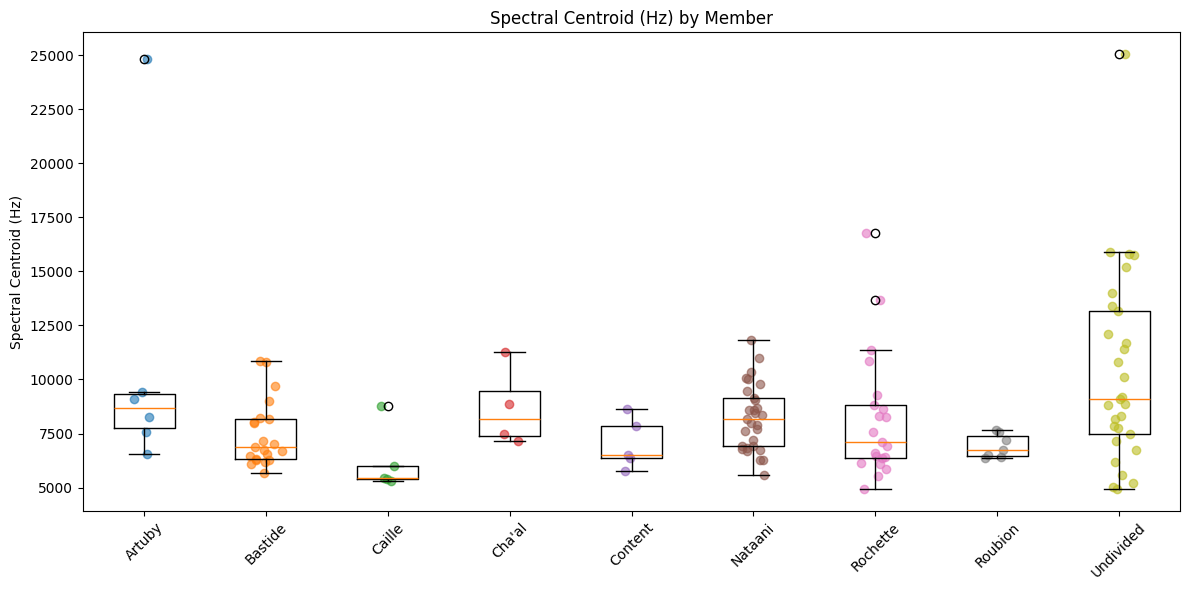

C:\Users\cmkua\AppData\Local\Temp\ipykernel_35060\449163728.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=members)


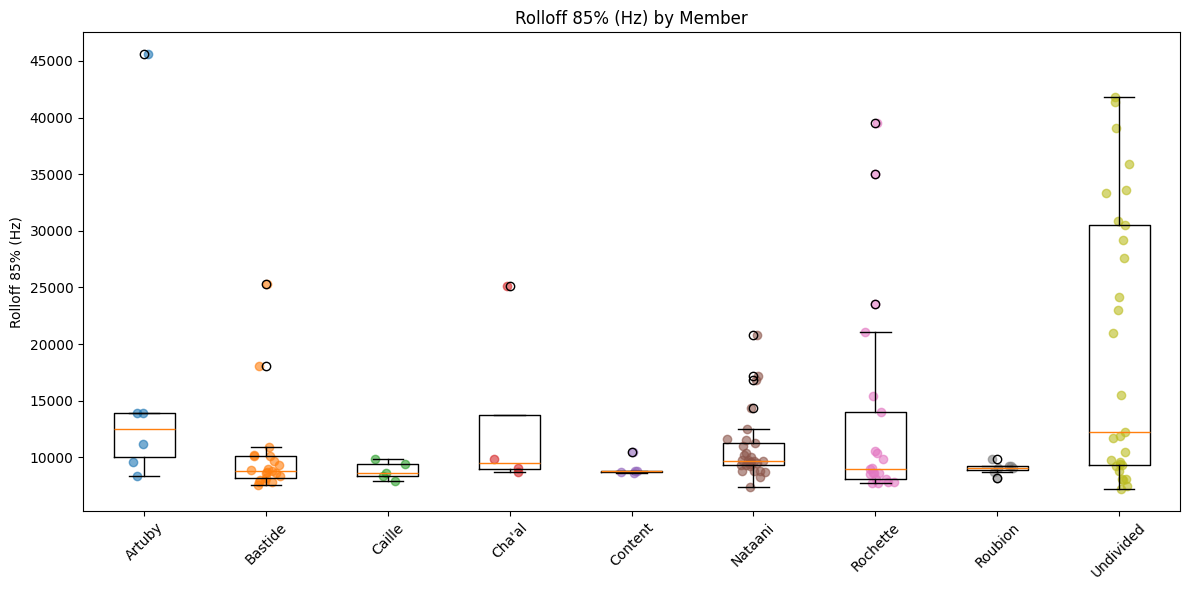

C:\Users\cmkua\AppData\Local\Temp\ipykernel_35060\449163728.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=members)


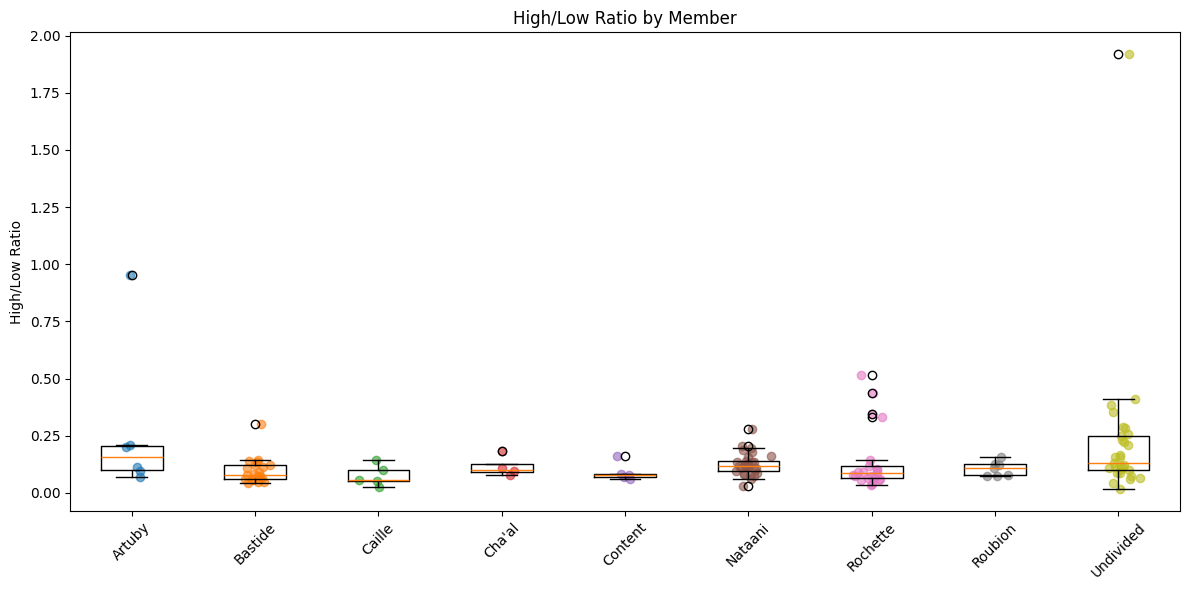

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

file_path = r"C:\Users\cmkua\Downloads\LIBS_acoustic_meta_sheet - LIBS_acoustic_meta_sheet.csv"
df = pd.read_csv(file_path)

metrics = [
    "Spectral Centroid (Hz)",
    "Rolloff 85% (Hz)",
    "High/Low Ratio"
]

for metric in metrics:

    fig, ax = plt.subplots(figsize=(12,6))

    members = sorted(df["Member"].dropna().unique())

    data = [
        df[df["Member"] == m][metric].dropna()
        for m in members
    ]

    ax.boxplot(data, labels=members)

    for i, m in enumerate(members):
        y = df[df["Member"] == m][metric].dropna()
        x = np.random.normal(i + 1, 0.06, len(y))
        ax.scatter(x, y, alpha=0.6)

    ax.set_title(f"{metric} by Member")
    ax.set_ylabel(metric)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

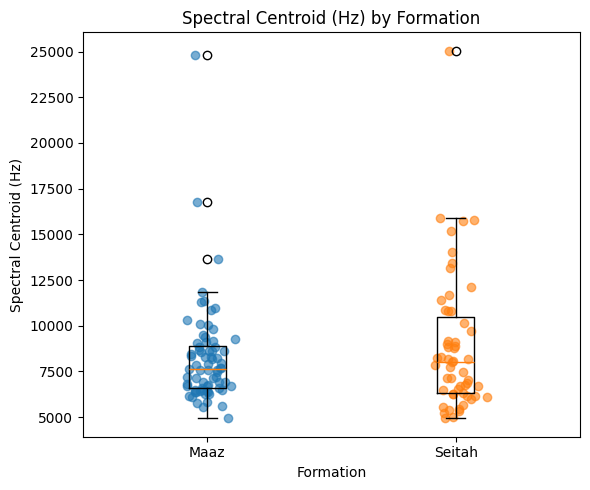

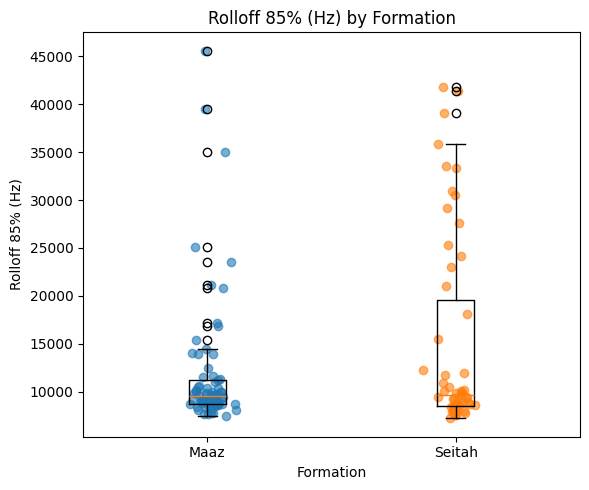

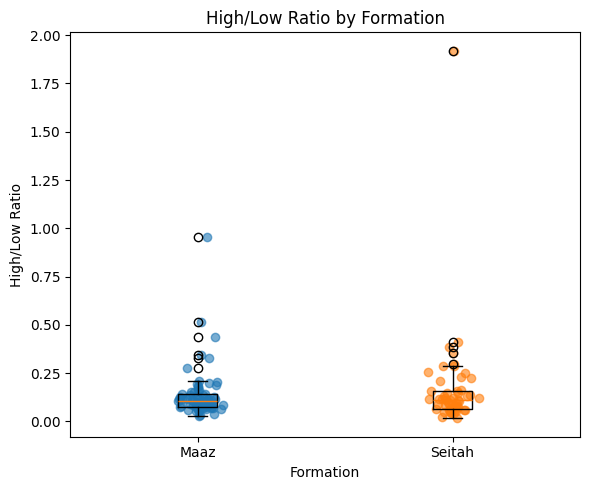

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

file_path = r"C:\Users\cmkua\Downloads\LIBS_acoustic_meta_sheet - LIBS_acoustic_meta_sheet.csv"
df = pd.read_csv(file_path)

seitah_members = ["Bastide", "Undivided", "Caille"]

df["Formation"] = df["Member"].apply(
    lambda m: "Seitah" if m in seitah_members else "Maaz"
)

metrics = [
    "Spectral Centroid (Hz)",
    "Rolloff 85% (Hz)",
    "High/Low Ratio"
]

for metric in metrics:
    fig, ax = plt.subplots(figsize=(6, 5))

    formations = ["Maaz", "Seitah"]

    data = [
        df[df["Formation"] == form][metric].dropna()
        for form in formations
    ]

    ax.boxplot(data, tick_labels=formations)

    for i, form in enumerate(formations):
        y = df[df["Formation"] == form][metric].dropna()
        x = np.random.normal(i + 1, 0.04, len(y))
        ax.scatter(x, y, alpha=0.6)

    ax.set_title(f"{metric} by Formation")
    ax.set_xlabel("Formation")
    ax.set_ylabel(metric)

    plt.tight_layout()
    plt.show()